# Gene Similarity — region-resolved V/J distances

Germline V and J genes contribute fixed FR/CDR sub-regions to every receptor.
Using the region annotations baked into the gene library (generated with
[arda](https://github.com/antigenomics/arda); see
`mir.common.region_annotation`), this notebook compares **human** and **mouse**
gene similarity at three resolutions:

* **V gene** — full V sequence vs **paratope** (CDR1+CDR2) vs **framework** (FR1–FR3)
* **J gene** — full J sequence vs **CDR3 part** (the J contribution to CDR3) vs **FR4**

Each panel is a hierarchical clustermap of the symmetric germline distance
`d(a,b) = s(a,a) + s(b,b) − 2·s(a,b)` (BLOSUM62), with rows/columns coloured by
gene family.

In [1]:
import importlib.metadata as _meta
import sys as _sys
print(f"Python {_sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "numpy", "pandas", "matplotlib", "scipy", "polars", "seaborn"]:
    try:
        print(f"  {_pkg}: {_meta.version(_pkg)}")
    except _meta.PackageNotFoundError:
        pass

import sys
sys.path.insert(0, "..")
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from mir.common import GeneLibrary
from mir.distances import GermlineAligner

sns.set_context("notebook")

Python 3.11.15
  mirpy-lib: 1.1.1
  numpy: 2.4.6
  pandas: 2.3.3
  matplotlib: 3.10.9
  scipy: 1.17.1
  polars: 1.41.2
  seaborn: 0.13.2


In [2]:
# Configuration and helpers
SPECIES = ["human", "mouse"]
LOCUS = "TRB"  # try "TRA" too; both carry full region annotations

# (label, gene, regions) — regions=None means the full gene amino-acid sequence.
V_FEATURES = [
    ("Full V", "V", None),
    ("Paratope (CDR1+CDR2)", "V", ["cdr1", "cdr2"]),
    ("Framework (FR1-3)", "V", ["fwr1", "fwr2", "fwr3"]),
]
J_FEATURES = [
    ("Full J", "J", None),
    ("CDR3 part", "J", ["jcdr3"]),
    ("FR4", "J", ["fwr4"]),
]


def feature_seqs(lib, locus, gene, regions):
    """Return (allele, aa) pairs for a feature; concatenates regions when given."""
    if regions is None:
        return lib.get_sequences_aa(locus, gene)
    out = []
    for e in lib.get_entries(locus, gene):
        parts = [e.region_aa.get(r) for r in regions]
        if all(parts):
            out.append((e.allele, "".join(parts)))
    return out


def family_colors(genes):
    """Map each allele to a colour by its gene family (e.g. TRBV10)."""
    fams = [re.split(r"[-*]", g)[0] for g in genes]
    uniq = list(dict.fromkeys(fams))
    pal = dict(zip(uniq, sns.color_palette("husl", len(uniq)).as_hex()))
    return pd.Series({g: pal[f] for g, f in zip(genes, fams)})


def plot_feature_clustermap(seqs, title):
    """Build the germline distance matrix for *seqs* and draw a clustermap."""
    if len(seqs) < 3:
        print(f"[skip] {title}: only {len(seqs)} annotated genes")
        return
    galn = GermlineAligner.from_seqs(seqs)
    genes = [a for a, _ in seqs]
    mat = pd.DataFrame(
        [[galn.score_dist(g1, g2) for g2 in genes] for g1 in genes],
        index=genes, columns=genes,
    )
    colors = family_colors(genes)
    side = min(0.12 * len(genes) + 3, 16)
    g = sns.clustermap(
        mat, cmap="mako", row_colors=colors, col_colors=colors,
        figsize=(side, side), xticklabels=False, yticklabels=False,
    )
    g.figure.suptitle(title, fontsize=14, y=1.02)
    plt.show()

## Human TRB

### V gene

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


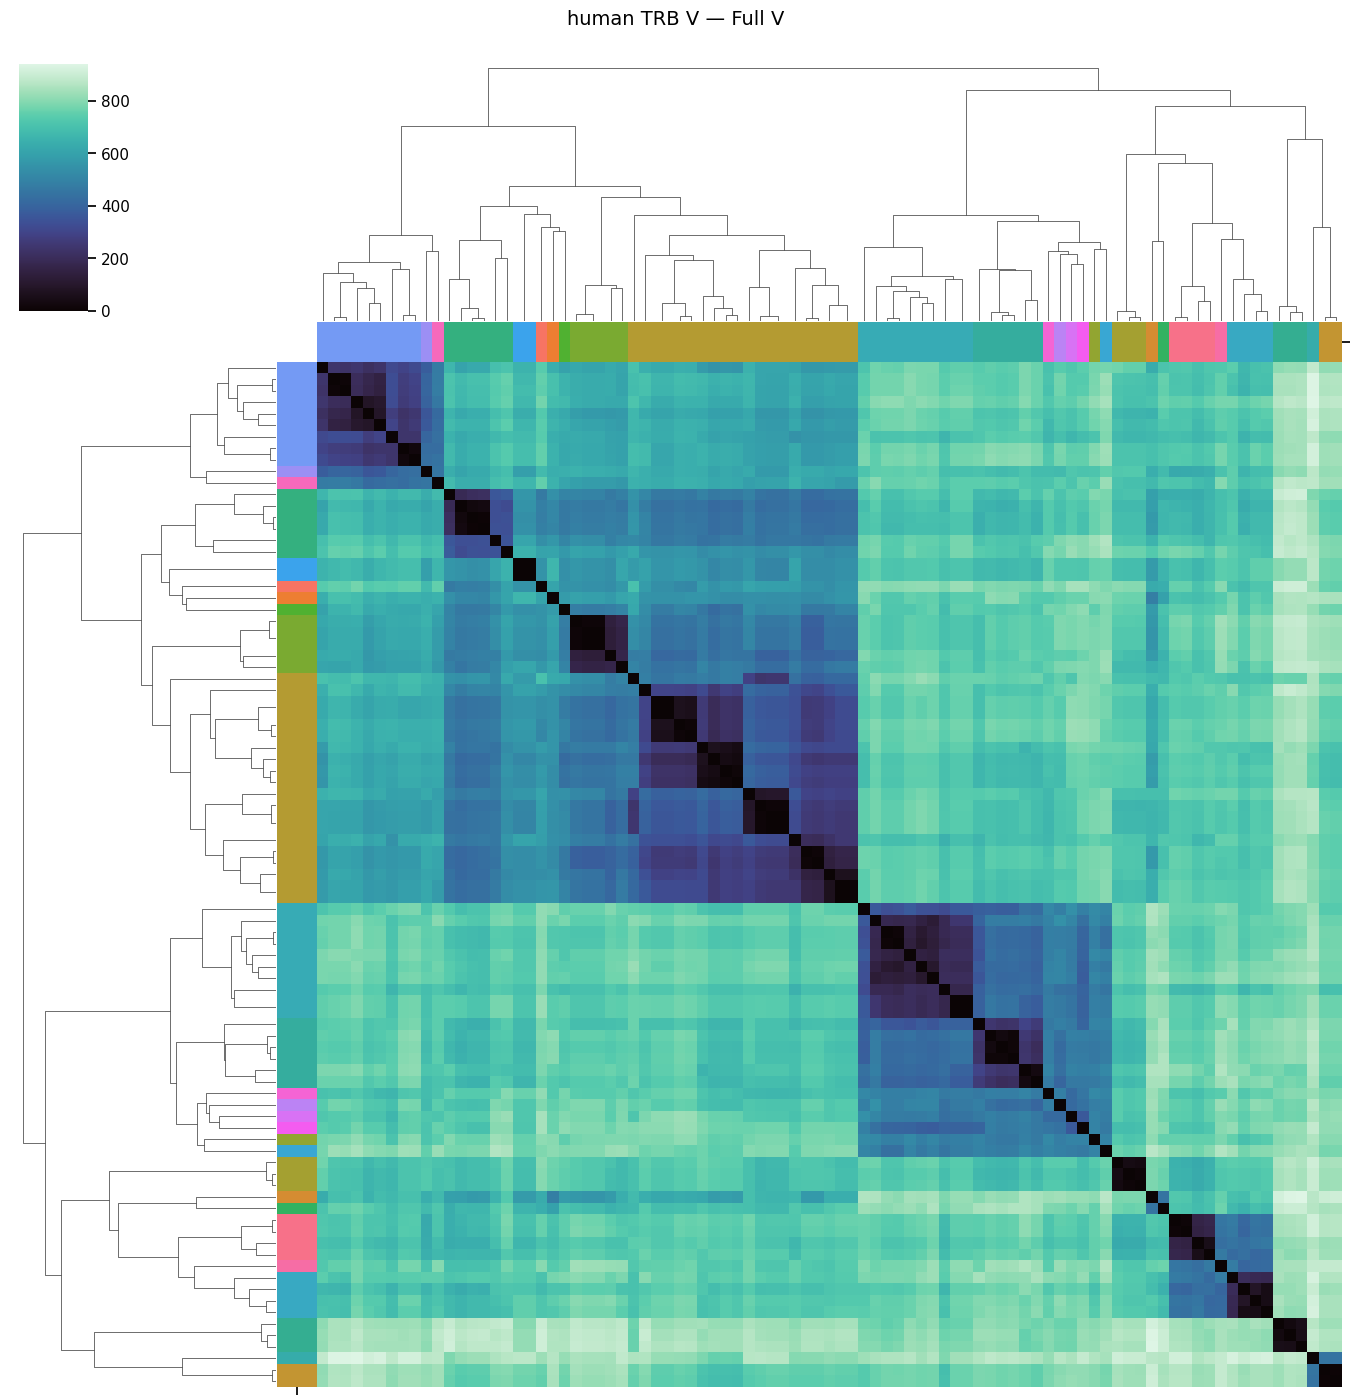

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


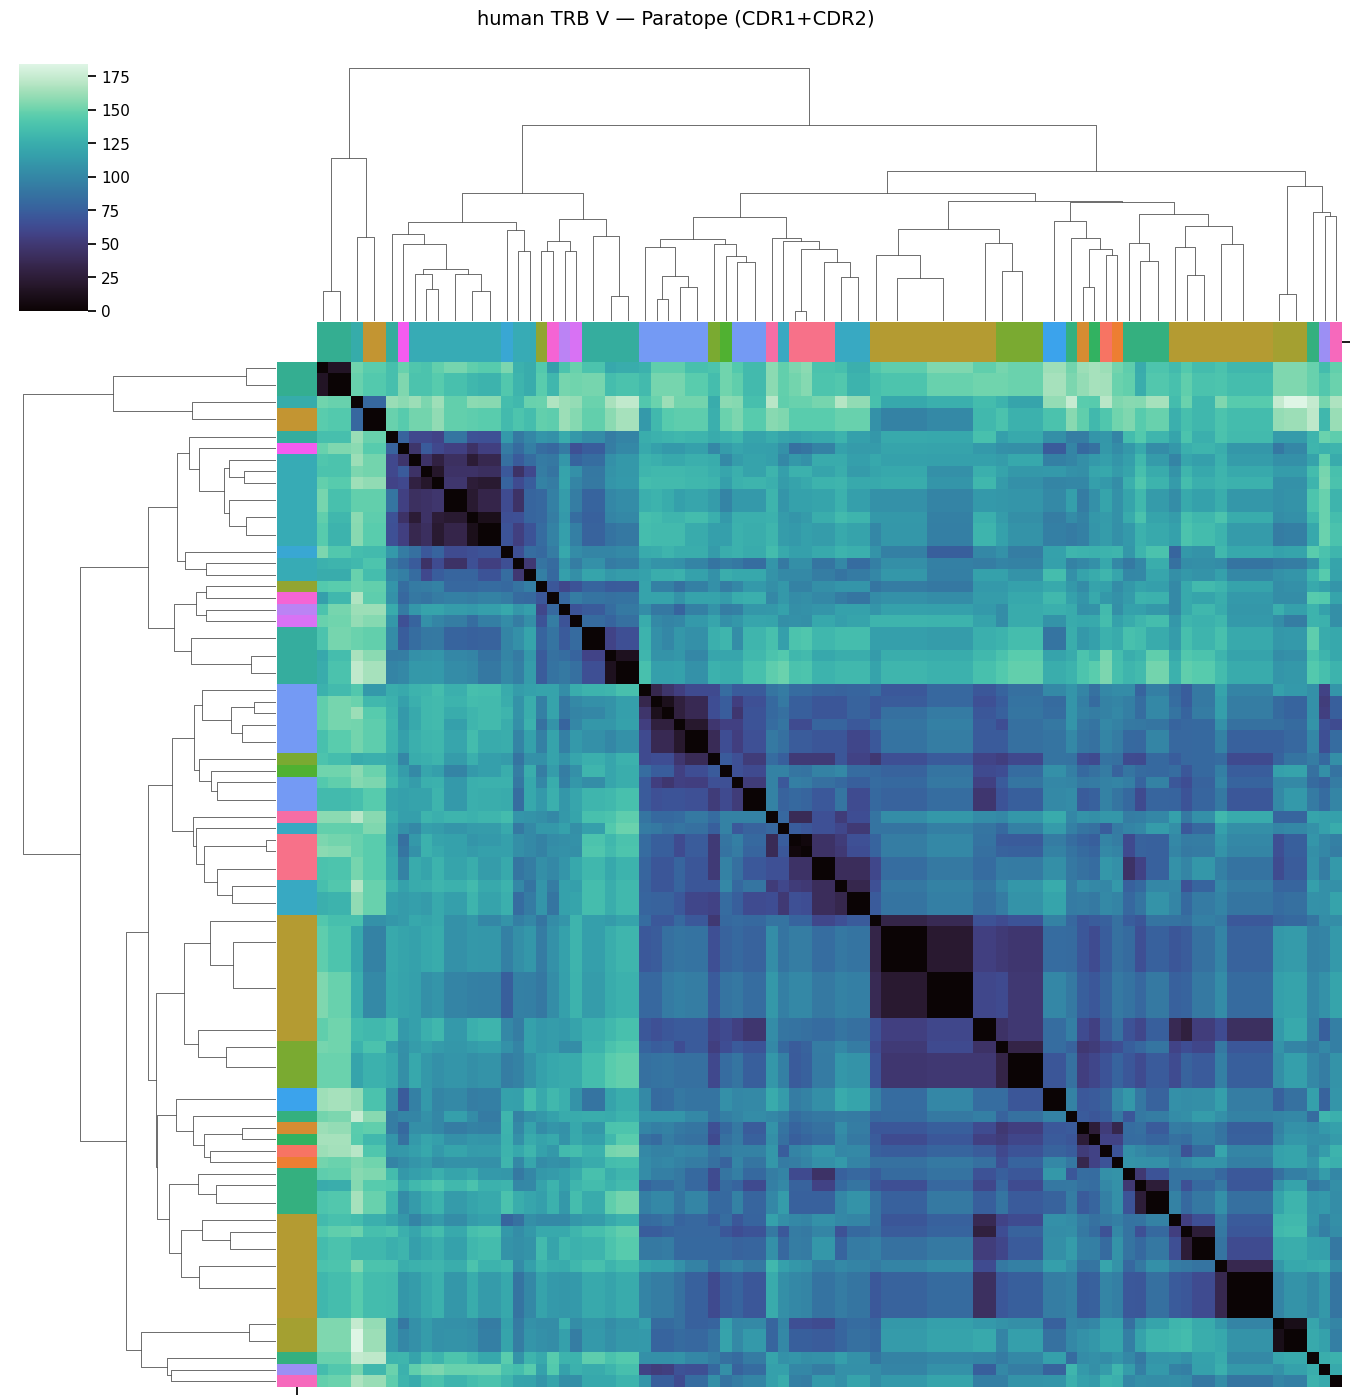

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


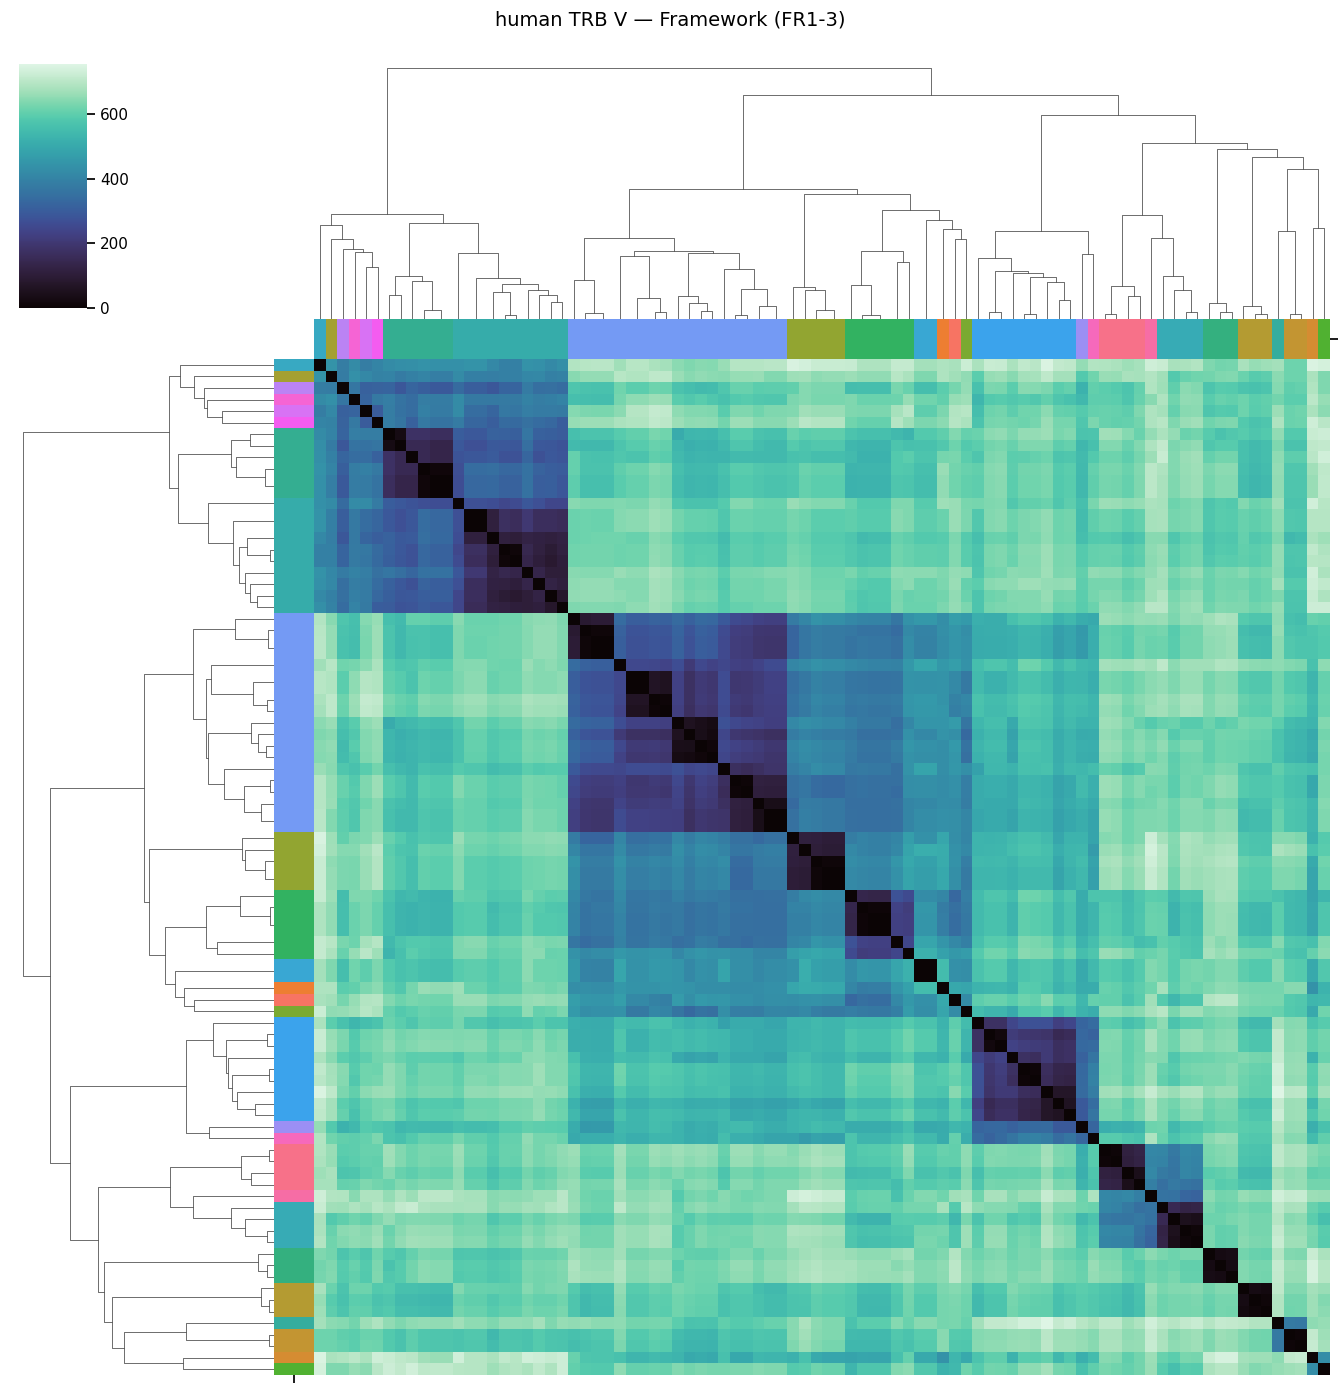

### J gene

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


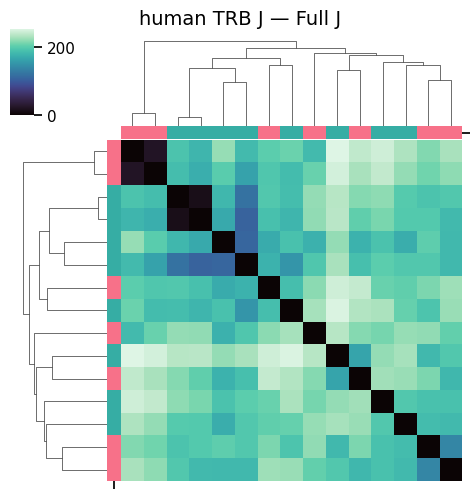

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


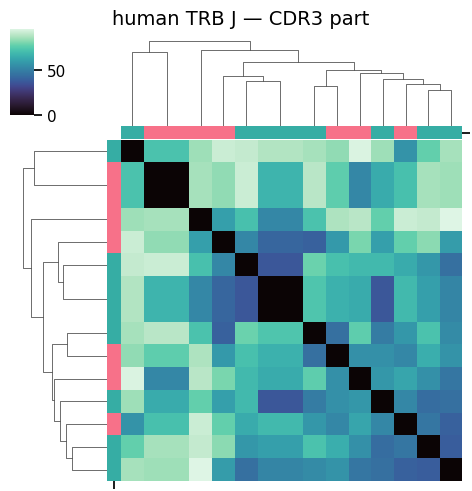

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


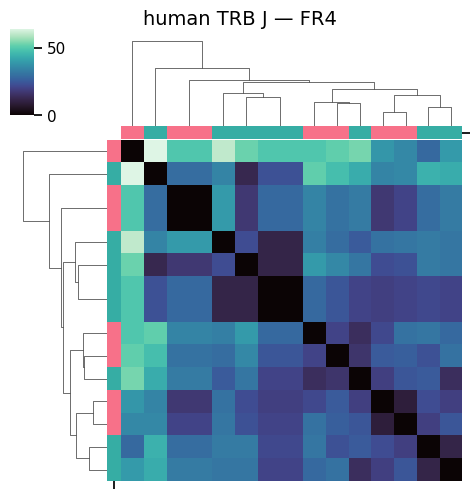

## Mouse TRB

### V gene

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


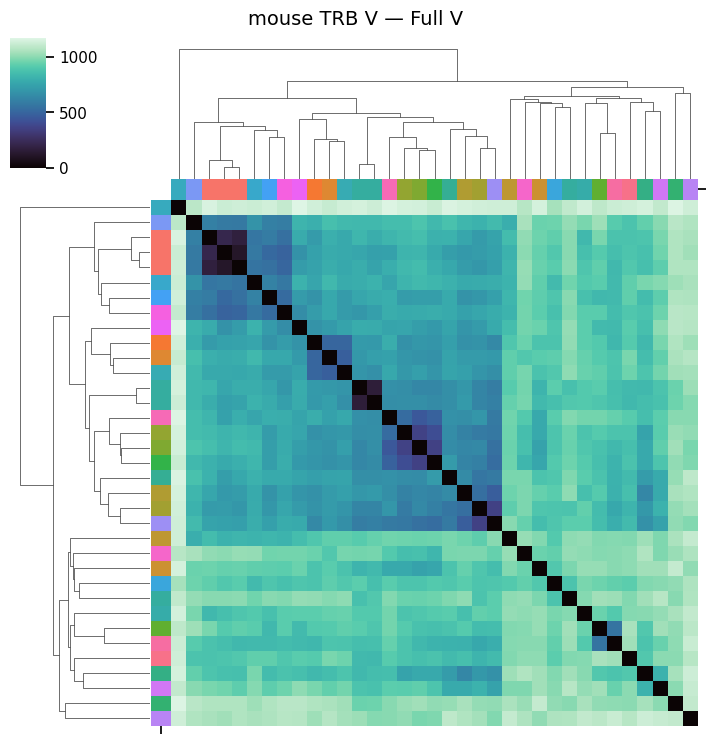

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


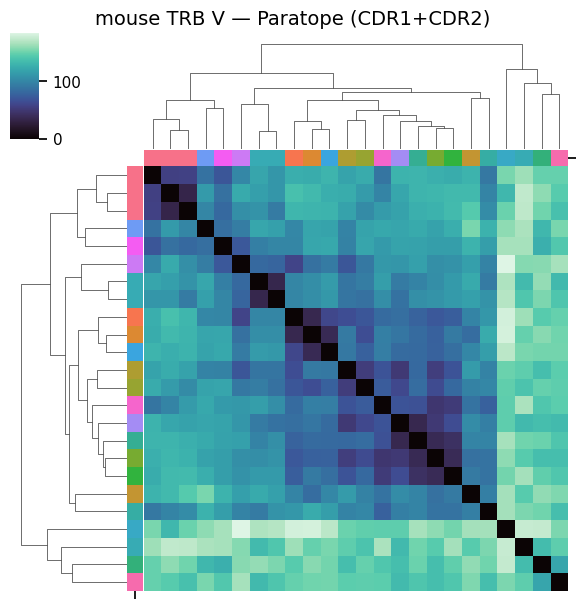

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


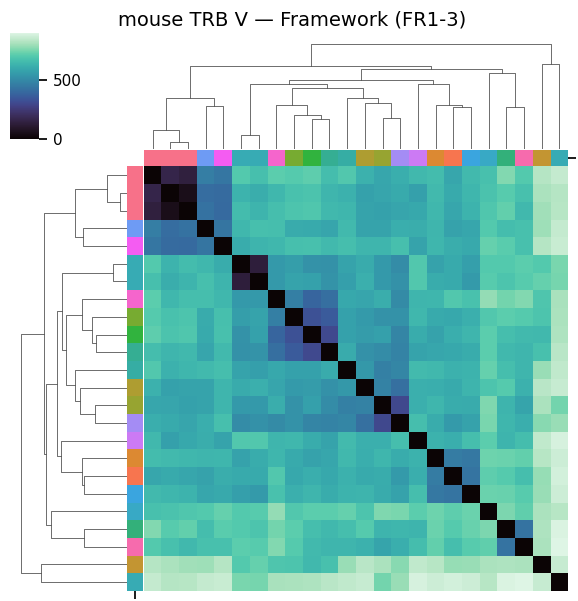

### J gene

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


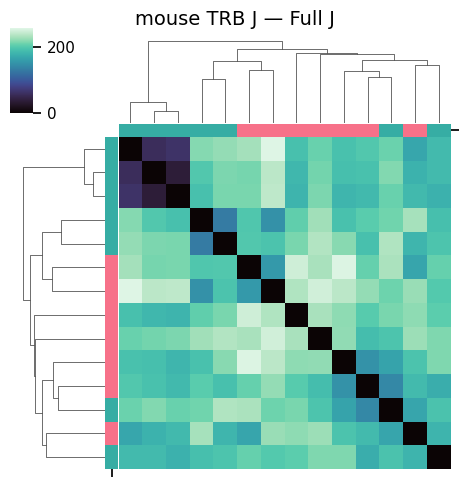

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


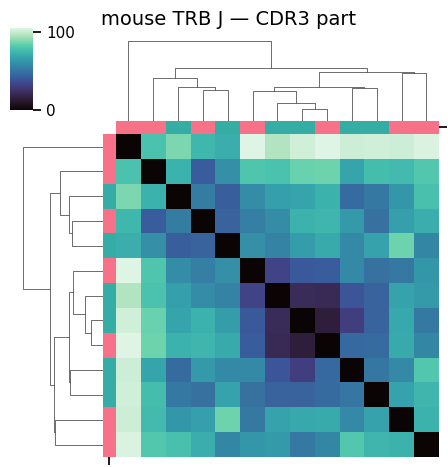

/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/homebrew/anaconda3/envs/mirpy-nb/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


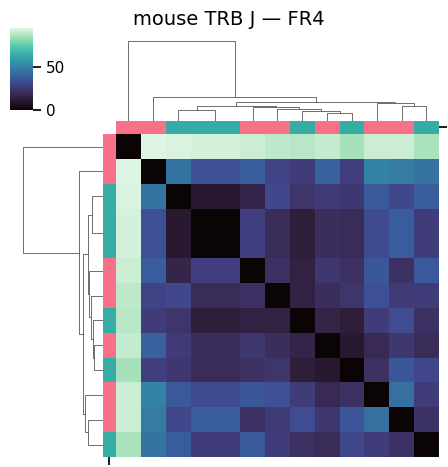

In [3]:
# Region-resolved similarity heatmaps for each species
for sp in SPECIES:
    lib = GeneLibrary.load_default(loci={LOCUS}, species={sp})
    display(Markdown(f"## {sp.capitalize()} {LOCUS}"))

    display(Markdown("### V gene"))
    for label, gene, regions in V_FEATURES:
        plot_feature_clustermap(
            feature_seqs(lib, LOCUS, gene, regions), f"{sp} {LOCUS} V — {label}"
        )

    display(Markdown("### J gene"))
    for label, gene, regions in J_FEATURES:
        plot_feature_clustermap(
            feature_seqs(lib, LOCUS, gene, regions), f"{sp} {LOCUS} J — {label}"
        )